# Create data structure for loading initial data

In [1]:
import pandas as pd
import os

DATASETS_PATH = os.getenv("DATASETS_PATH")

class GroceryRetailSalesData:
    def __init__(self):
        self._df_calendar = pd.read_csv(DATASETS_PATH + "/RetailOptimizationProject/m5-forecasting-accuracy/calendar.csv")
        self._df_sell_prices = pd.read_csv(DATASETS_PATH + "/RetailOptimizationProject/m5-forecasting-accuracy/sell_prices.csv")
        self._df_sales_validation = pd.read_csv(DATASETS_PATH + "/RetailOptimizationProject/m5-forecasting-accuracy/sales_train_validation.csv")
        self._df_sales_evaluation = pd.read_csv(DATASETS_PATH + "/RetailOptimizationProject/m5-forecasting-accuracy/sales_train_evaluation.csv")
        self._store_ids = self._df_sales_validation['store_id'].unique()

initial_data = GroceryRetailSalesData()

# Create cumulative sales per day for each store 

In [2]:
def generate_cumulative_sales_time_series(initial_data: GroceryRetailSalesData):
    df = initial_data._df_sales_evaluation

    # Identify day columns
    day_cols = df.columns[df.columns.str.startswith('d_')].tolist()

    # Aggregate across items per store (vectorized)
    df_grouped = df.groupby('store_id')[day_cols].sum()

    # Convert wide → long format
    df_long = df_grouped.stack().reset_index()
    df_long.columns = ['store_id', 'd', 'y']

    # Merge with calendar
    df_long = df_long.merge(
        initial_data._df_calendar[['d', 'date']],
        on='d',
        how='left'
    )

    # Set MultiIndex
    df_long = df_long.set_index(['store_id', 'd'])
    
    df_long = df_long.reindex(columns=['date', 'y'])
    
    return df_long

cumulative_sales_time_series = generate_cumulative_sales_time_series(initial_data)

print(cumulative_sales_time_series)

                       date     y
store_id d                       
CA_1     d_1     2011-01-29  4337
         d_2     2011-01-30  4155
         d_3     2011-01-31  2816
         d_4     2011-02-01  3051
         d_5     2011-02-02  2630
...                     ...   ...
WI_3     d_1937  2016-05-18  3268
         d_1938  2016-05-19  3398
         d_1939  2016-05-20  4126
         d_1940  2016-05-21  4519
         d_1941  2016-05-22  4757

[19410 rows x 2 columns]


In [3]:
%timeit -n 2 cumulative_sales_time_series = generate_cumulative_sales_time_series(initial_data)

366 ms ± 12.2 ms per loop (mean ± std. dev. of 7 runs, 2 loops each)


# Fit Prophet models to the cumulative sales time series

In [4]:
from joblib import Parallel, delayed
from prophet import Prophet

def fit_single_store(store, df_store):
    df_loc = df_store.reset_index()[['date', 'y']].rename(columns={'date': 'ds'})
    model = Prophet(interval_width=0.95)
    model.fit(df_loc)
    return store, model

def fit_prophet_models(df_long, n_jobs=-1):
    results = Parallel(n_jobs=n_jobs)(
        delayed(fit_single_store)(store, df_store)
        for store, df_store in df_long.groupby(level=0)
    )
    
    return dict(results)

train_df = cumulative_sales_time_series.groupby(level="store_id", group_keys=False).apply(lambda x: x.iloc[:-28])

prophet_models = fit_prophet_models(train_df)

print(prophet_models)

{'CA_1': <prophet.forecaster.Prophet object at 0x000001C60F6ACEC0>, 'CA_2': <prophet.forecaster.Prophet object at 0x000001C60D9F81A0>, 'CA_3': <prophet.forecaster.Prophet object at 0x000001C60D9F8EC0>, 'CA_4': <prophet.forecaster.Prophet object at 0x000001C60F6ACC20>, 'TX_1': <prophet.forecaster.Prophet object at 0x000001C60F6AC980>, 'TX_2': <prophet.forecaster.Prophet object at 0x000001C60D9F82F0>, 'TX_3': <prophet.forecaster.Prophet object at 0x000001C60D9F8D70>, 'WI_1': <prophet.forecaster.Prophet object at 0x000001C60F6ACAD0>, 'WI_2': <prophet.forecaster.Prophet object at 0x000001C60F6ACD70>, 'WI_3': <prophet.forecaster.Prophet object at 0x000001C60F6AD010>}


In [5]:
%timeit prophet_models = fit_prophet_models(cumulative_sales_time_series)

1.48 s ± 51.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# Make Prophet forecast for each store

In [6]:
import pandas as pd

def forecast_single(store_id, model, future_days):
    # Generate future dataframe and predict
    future = model.make_future_dataframe(periods=future_days)
    forecast = model.predict(future)

    # Keep only relevant columns and add store_id
    df = forecast[['ds', 'yhat_lower', 'yhat_upper', 'yhat']].copy()
    df['store_id'] = store_id
    return df

def generate_prophet_forecasts_parallel(prophet_models, future_days=28, n_jobs=-1):
    # Parallel prediction
    results = Parallel(n_jobs=n_jobs)(
        delayed(forecast_single)(store_id, model, future_days)
        for store_id, model in prophet_models.items()
    )

    # Concatenate all results into one DataFrame
    df = pd.concat(results, ignore_index=True)

    # Set MultiIndex for clean alignment
    df = df.set_index(['store_id', 'ds']).sort_index()

    return df

df_cumulative_sales_forecasts = generate_prophet_forecasts_parallel(prophet_models, future_days=28)
print(df_cumulative_sales_forecasts)

                      yhat_lower   yhat_upper         yhat
store_id ds                                               
CA_1     2011-01-29  3027.831772  4822.555365  3917.537422
         2011-01-30  3085.738574  4857.281662  3991.203969
         2011-01-31  1851.520818  3563.480746  2725.109736
         2011-02-01  1375.416342  3268.993416  2290.586326
         2011-02-02  1327.051422  3163.445993  2207.502741
...                          ...          ...          ...
WI_3     2016-05-18  2176.329620  4337.564876  3235.258845
         2016-05-19  2177.916345  4300.955481  3288.174223
         2016-05-20  2677.888269  4886.394317  3834.963744
         2016-05-21  3449.492017  5554.969484  4464.484700
         2016-05-22  3013.141224  5319.290536  4213.585153

[19410 rows x 3 columns]


In [7]:
timeit -n 2 df_cumulative_sales_forecasts = generate_prophet_forecasts_parallel(prophet_models, future_days=28)

641 ms ± 14.7 ms per loop (mean ± std. dev. of 7 runs, 2 loops each)


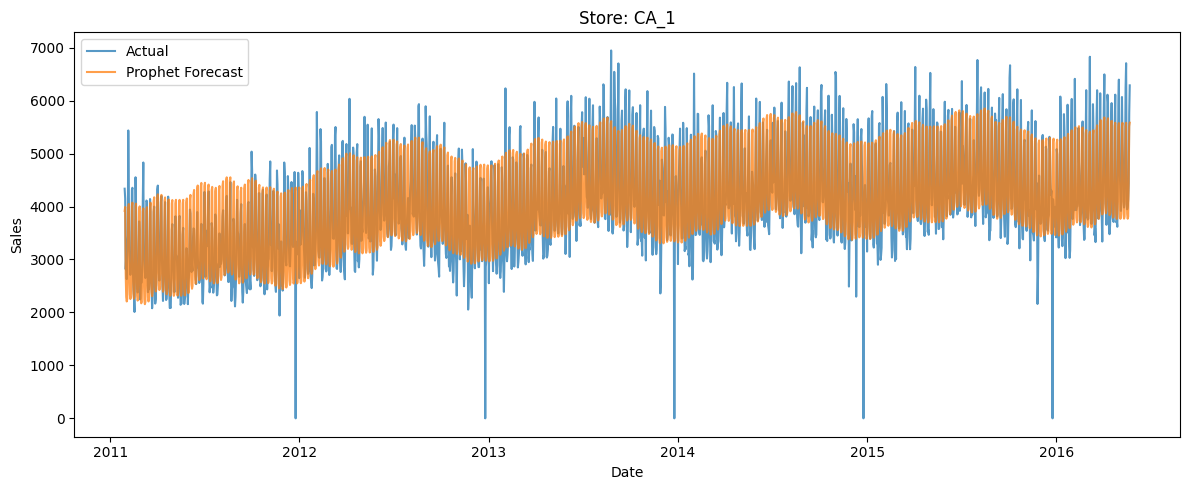

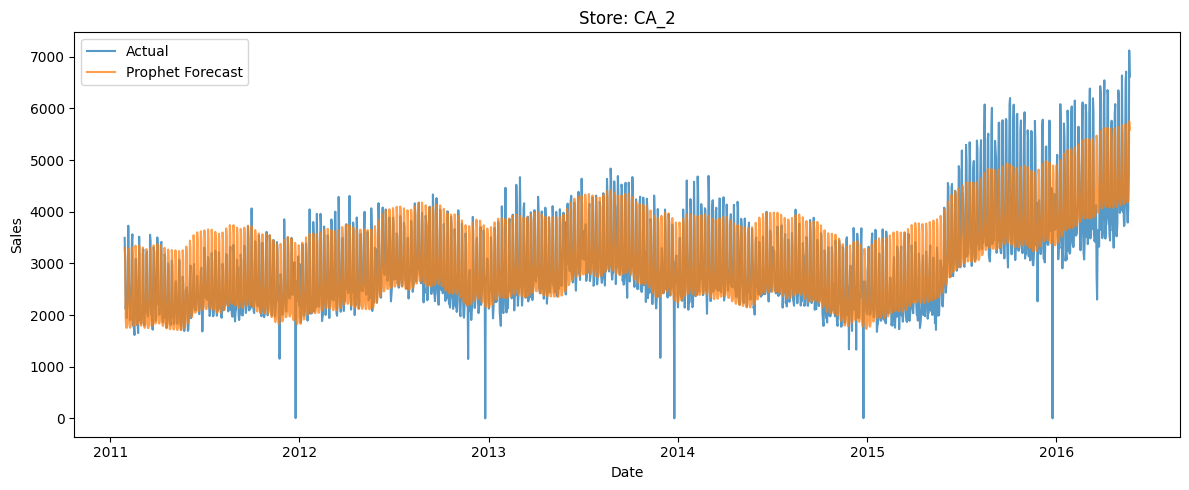

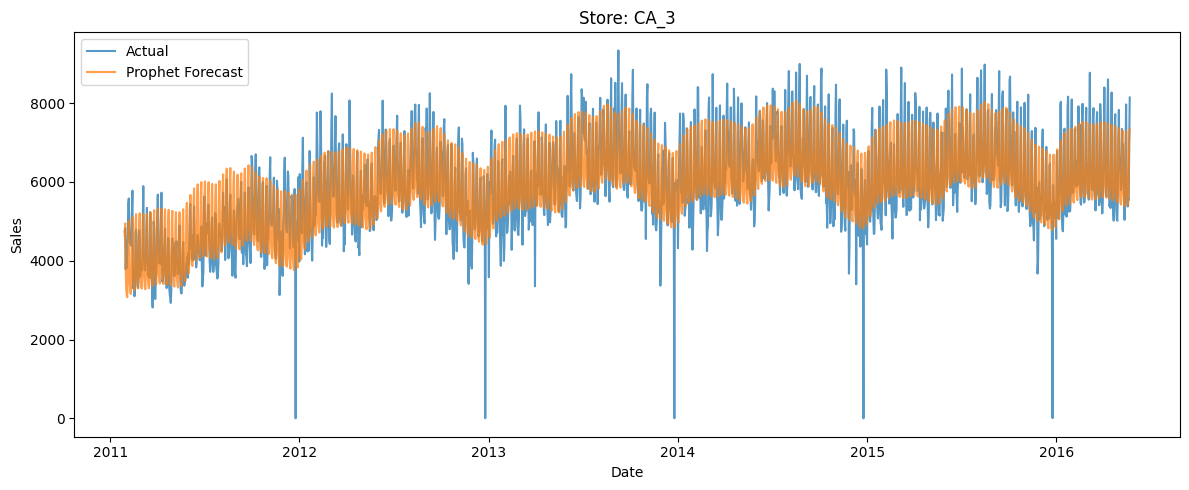

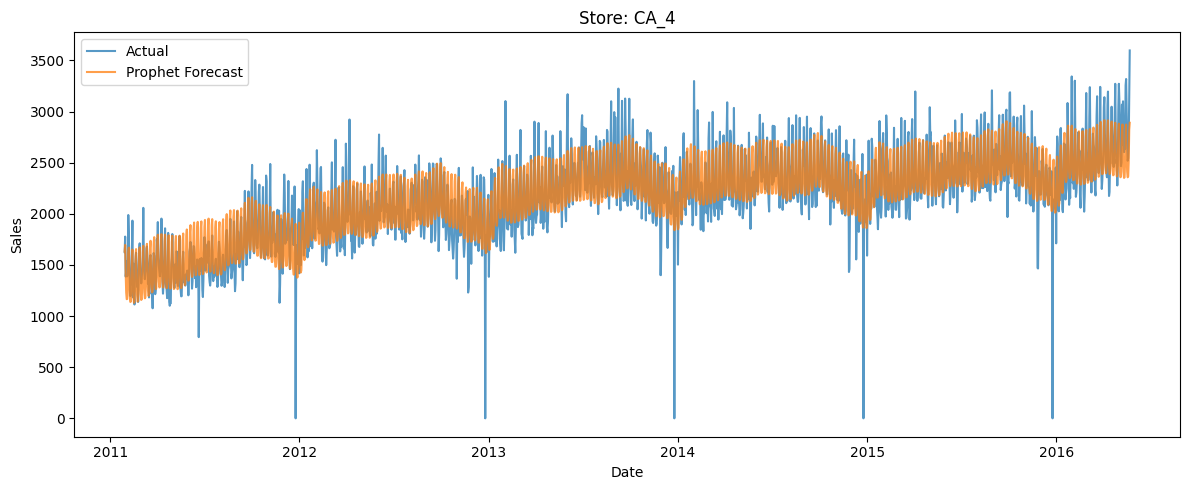

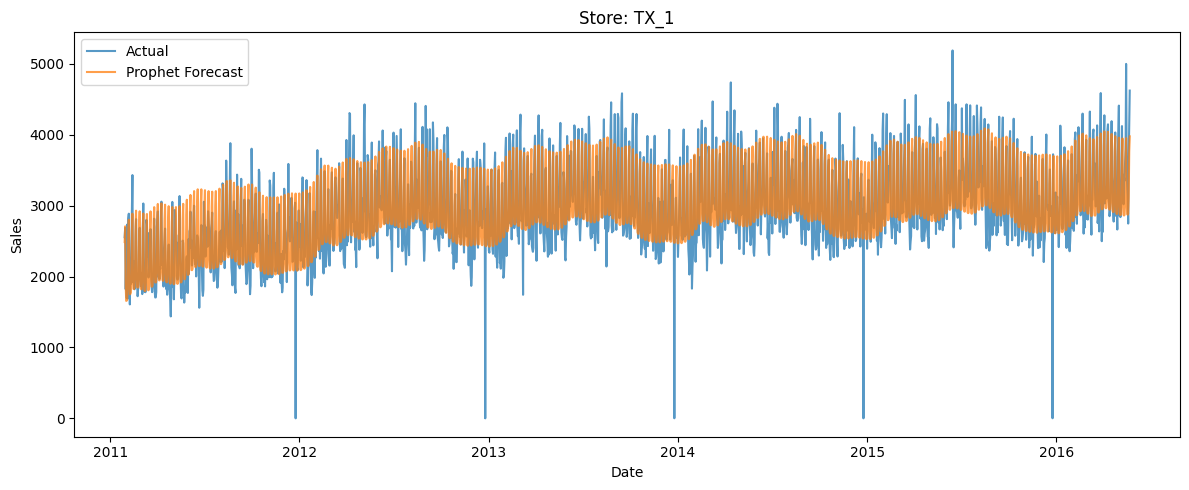

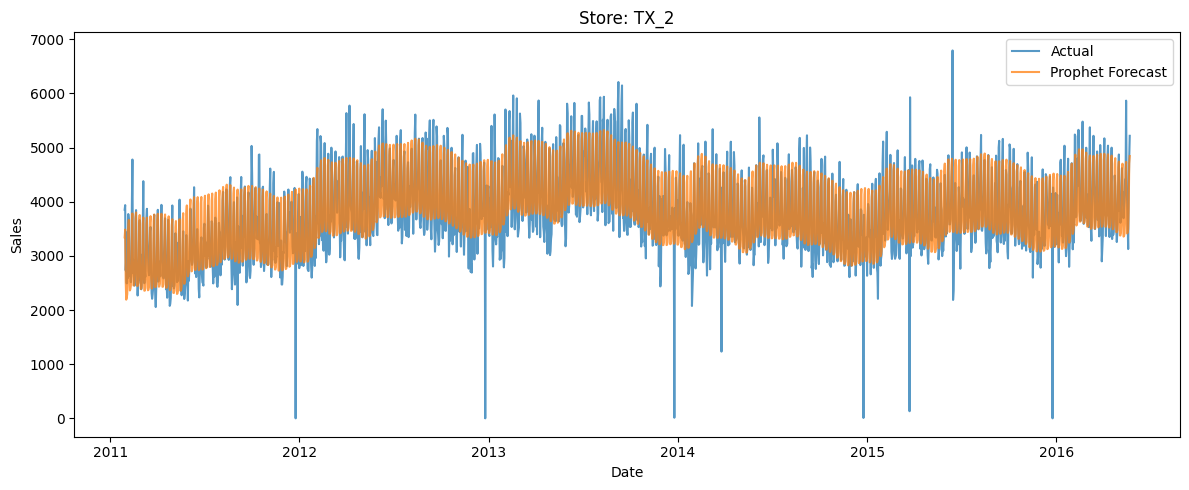

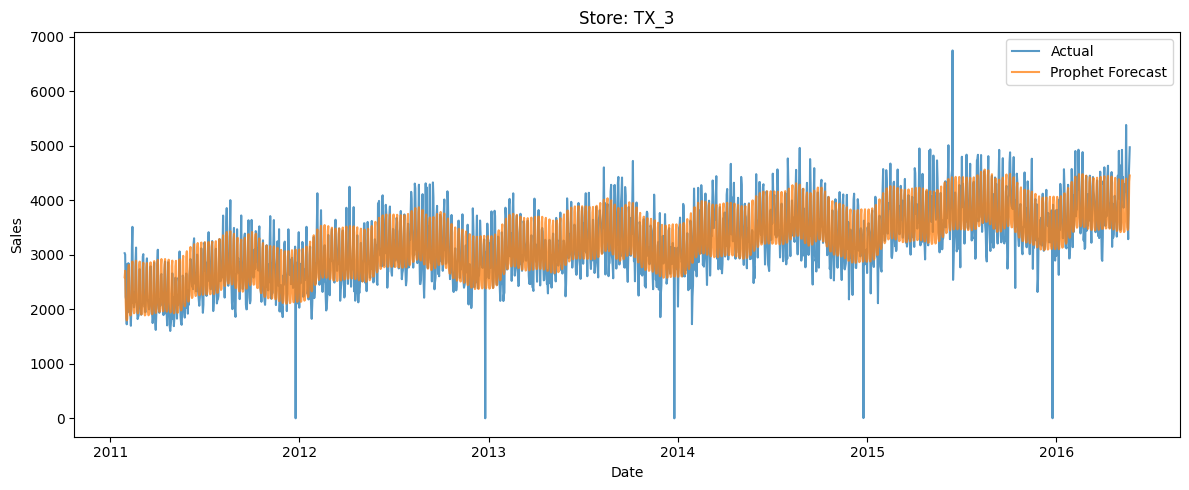

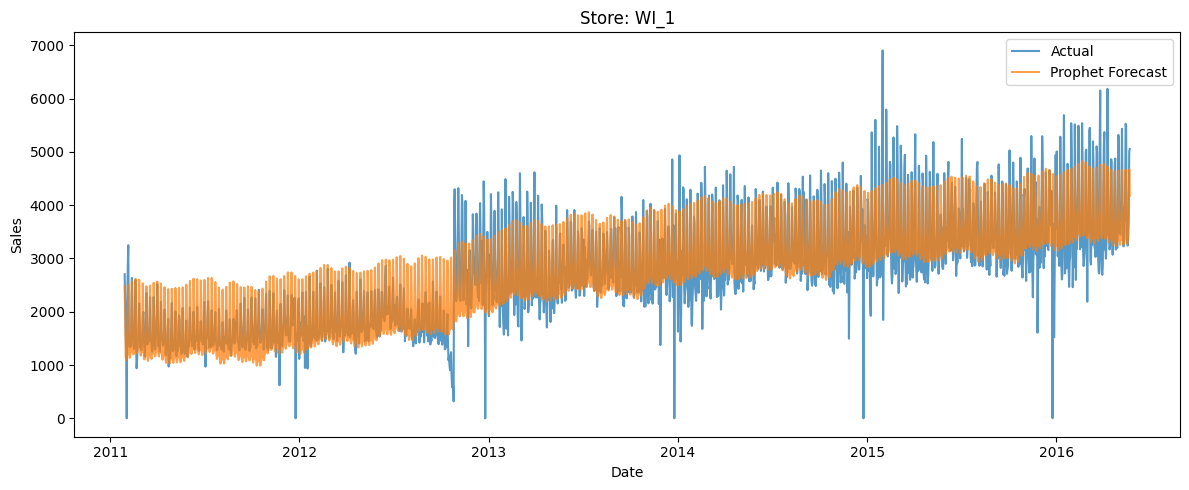

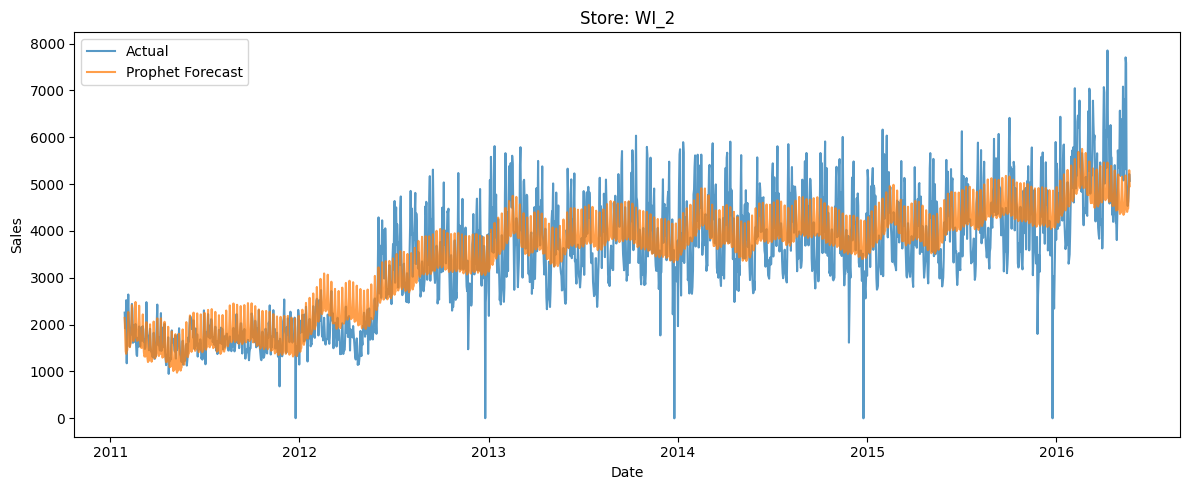

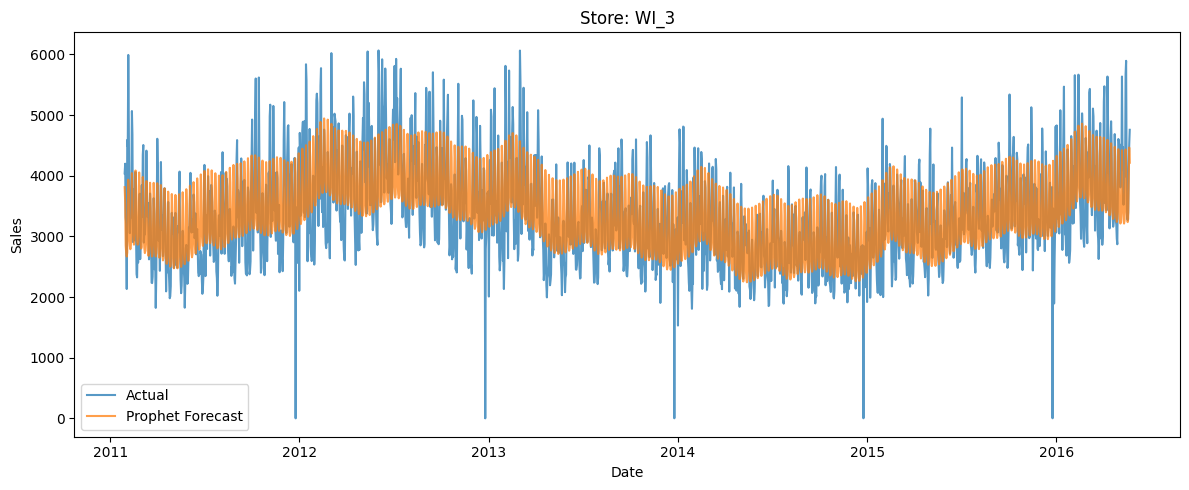

In [8]:
import matplotlib.pyplot as plt

# Reset index to merge easily
df_actual = cumulative_sales_time_series.reset_index().rename(columns={'d':'d', 'date':'ds'})
df_actual['ds'] = pd.to_datetime(df_actual['ds'])

df_forecast = df_cumulative_sales_forecasts.reset_index()

# Merge actuals and forecast on store_id and date
df_plot = pd.merge(
    df_actual[['store_id','ds','y']],
    df_forecast[['store_id','ds','yhat']],
    on=['store_id','ds'],
    how='outer'
)

stores = df_plot['store_id'].unique()

for store in stores:
    df_store = df_plot[df_plot['store_id'] == store]

    plt.figure(figsize=(12,5))
    plt.plot(df_store['ds'], df_store['y'], label='Actual', alpha=0.75)
    plt.plot(df_store['ds'], df_store['yhat'], label='Prophet Forecast', alpha=0.75)
    
    plt.title(f'Store: {store}')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Generate a prices table per item for each store.

In [9]:
# fastest version compared to vectorized and parallel implementations (approx. 10 times faster then any of them) 
def generate_item_prices_per_day(initial_data):
    result = {}

    df_calendar = initial_data._df_calendar[['d','wm_yr_wk']]

    # Precompute item order per store ONCE
    df_items = (
        initial_data._df_sales_validation[['store_id','item_id']]
        .drop_duplicates()
    )

    item_order_per_store = {
        store: group['item_id'].tolist()
        for store, group in df_items.groupby('store_id')
    }

    # Pre-group prices (avoid repeated filtering)
    grouped_prices = initial_data._df_sell_prices.groupby('store_id')

    for store, df_store_prices in grouped_prices:

        pivot_prices = df_store_prices.pivot_table(
            index='wm_yr_wk',
            columns='item_id',
            values='sell_price',
            aggfunc='first'
        )

        # Restore original item order
        pivot_prices = pivot_prices.reindex(
            columns=item_order_per_store[store]
        )

        df = df_calendar.merge(
            pivot_prices.reset_index(),
            on='wm_yr_wk',
            how='left'
        ).set_index('d')

        result[store] = (
            df.drop(columns='wm_yr_wk', errors='ignore')
              .fillna(0)
        )

    return result

item_prices_per_day = generate_item_prices_per_day(initial_data)
print(item_prices_per_day)

{'CA_1':         HOBBIES_1_001  HOBBIES_1_002  HOBBIES_1_003  HOBBIES_1_004  \
d                                                                    
d_1              0.00           0.00           0.00           0.00   
d_2              0.00           0.00           0.00           0.00   
d_3              0.00           0.00           0.00           0.00   
d_4              0.00           0.00           0.00           0.00   
d_5              0.00           0.00           0.00           0.00   
...               ...            ...            ...            ...   
d_1965           8.38           3.97           2.97           4.64   
d_1966           8.38           3.97           2.97           4.64   
d_1967           8.38           3.97           2.97           4.64   
d_1968           8.38           3.97           2.97           4.64   
d_1969           8.38           3.97           2.97           4.64   

        HOBBIES_1_005  HOBBIES_1_006  HOBBIES_1_007  HOBBIES_1_008  \
d         

In [10]:
%timeit -n 1 -r 5 item_prices_per_day = generate_item_prices_per_day(initial_data)

3.55 s ± 12.1 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)


# Calculate price indexes for each group of items (hobbies, household, foods), which are weighted averages of items prices in each group

In [11]:
def calculate_price_indexes_per_store(initial_data, item_prices_per_day):
    day_cols = [col for col in initial_data._df_sales_validation.columns if col.startswith('d_')]
    
    total_sales_per_item = (
        initial_data._df_sales_validation[day_cols]
        .sum(axis=1)
        .groupby(initial_data._df_sales_validation['item_id'])
        .sum()
    )

    item_cat_map = initial_data._df_sales_validation[['item_id', 'cat_id']].drop_duplicates()
    sales_with_cat = total_sales_per_item.reset_index(name='total_sales').merge(
        item_cat_map,
        on='item_id',
        how='left'
    )
    total_sales_per_category = (
        sales_with_cat
        .groupby('cat_id')['total_sales']
        .sum()
    )

    sales_with_cat['cat_total'] = sales_with_cat['cat_id'].map(total_sales_per_category)

    sales_with_cat['weight'] = (
        sales_with_cat['total_sales'] / sales_with_cat['cat_total']
    )
    weights_by_cat = {}

    for cat in ['FOODS', 'HOBBIES', 'HOUSEHOLD']:
        df_cat = sales_with_cat[sales_with_cat['cat_id'] == cat]
        
        weights_by_cat[cat] = df_cat.set_index('item_id')['weight']

    features_per_store = {}

    for store in initial_data._store_ids:
        price_df = item_prices_per_day[store]
        
        features = pd.DataFrame(index=price_df.index)
        
        for cat in ['FOODS', 'HOBBIES', 'HOUSEHOLD']:
            
            weights = weights_by_cat[cat]
            
            # Align columns
            common_items = price_df.columns.intersection(weights.index)
            
            features[f'{cat}_price_index'] = (
                price_df[common_items] @ weights.loc[common_items]
            )
        features_per_store[store]=features.copy()

    normalized_features_per_store = {}

    for key, df in features_per_store.items():
        normalized_features_per_store[key] = features_per_store[key] / features_per_store[key].max()
    
    return normalized_features_per_store

price_indexes_per_store = calculate_price_indexes_per_store(initial_data, item_prices_per_day)
print(price_indexes_per_store)

{'CA_1':         FOODS_price_index  HOBBIES_price_index  HOUSEHOLD_price_index
d                                                                    
d_1              0.582897             0.401408               0.428361
d_2              0.582897             0.401408               0.428361
d_3              0.582897             0.401408               0.428361
d_4              0.582897             0.401408               0.428361
d_5              0.582897             0.401408               0.428361
...                   ...                  ...                    ...
d_1965           0.999960             0.993309               0.998298
d_1966           0.999960             0.993309               0.998298
d_1967           0.999960             0.993309               0.998298
d_1968           1.000000             0.992629               0.998184
d_1969           1.000000             0.992629               0.998184

[1969 rows x 3 columns], 'CA_2':         FOODS_price_index  HOBBIES_price_index 

In [12]:
%timeit -n 1 -r 5 price_indexes_per_store = calculate_price_indexes_per_store(initial_data, item_prices_per_day)

379 ms ± 20.8 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)


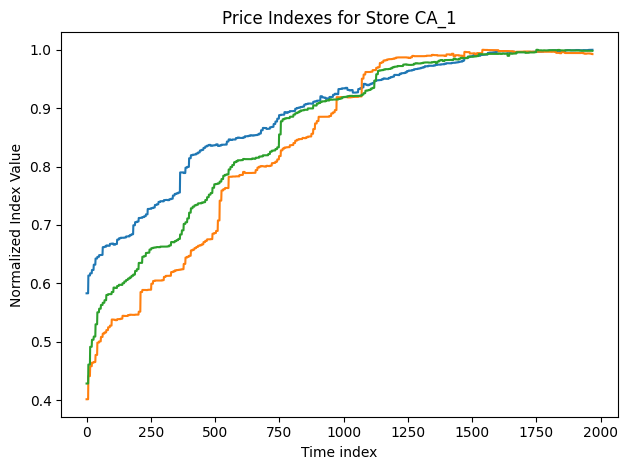

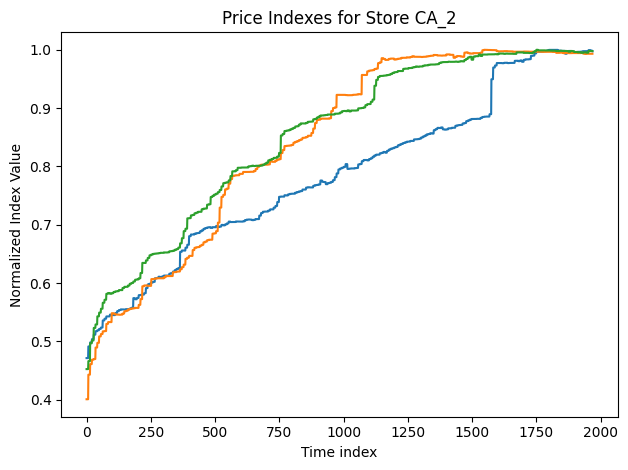

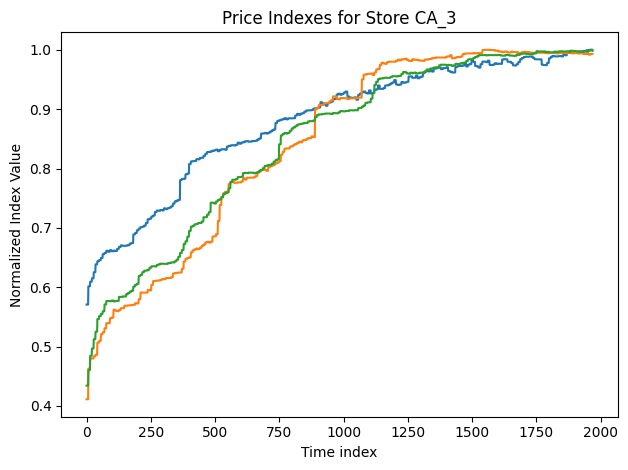

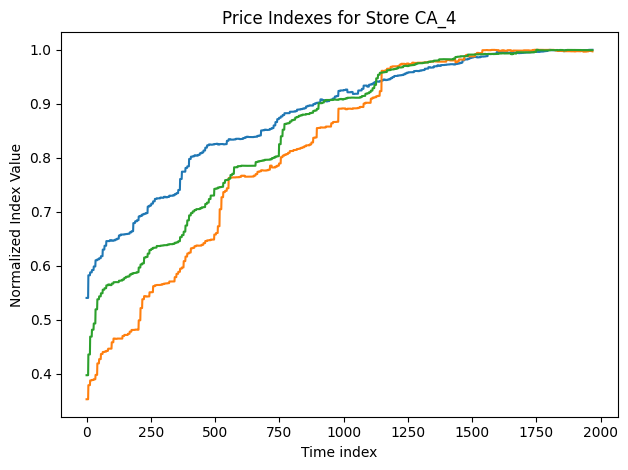

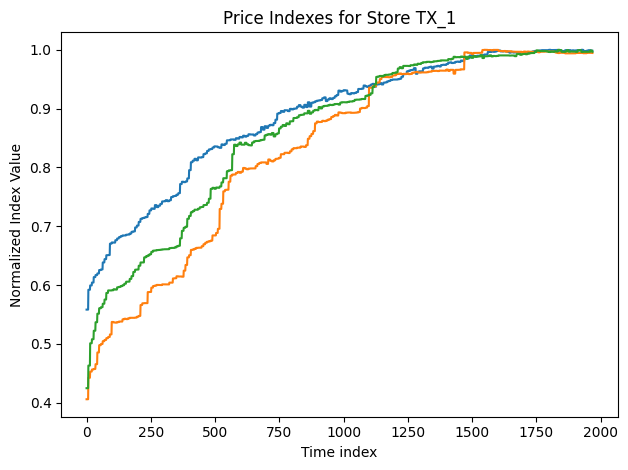

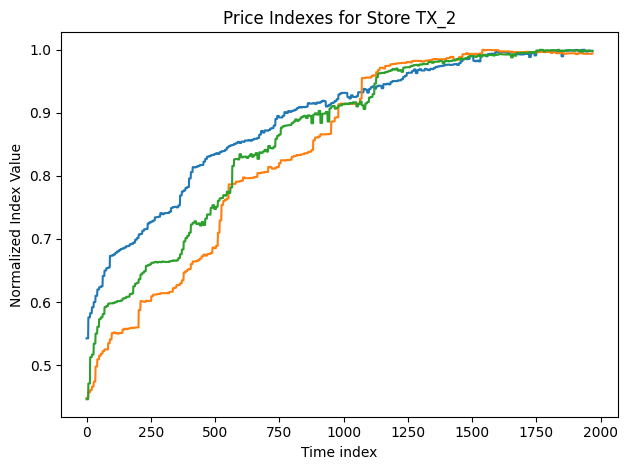

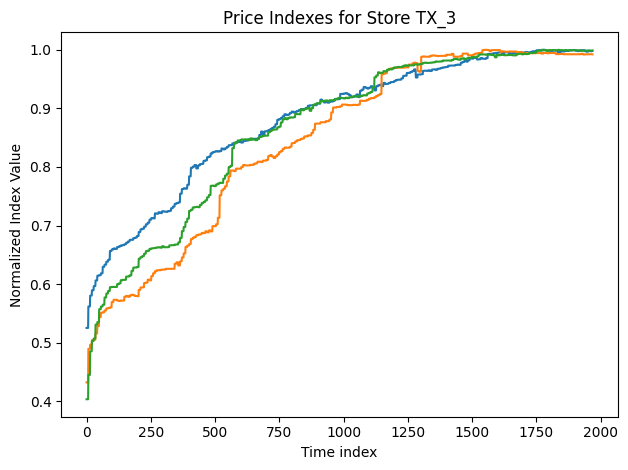

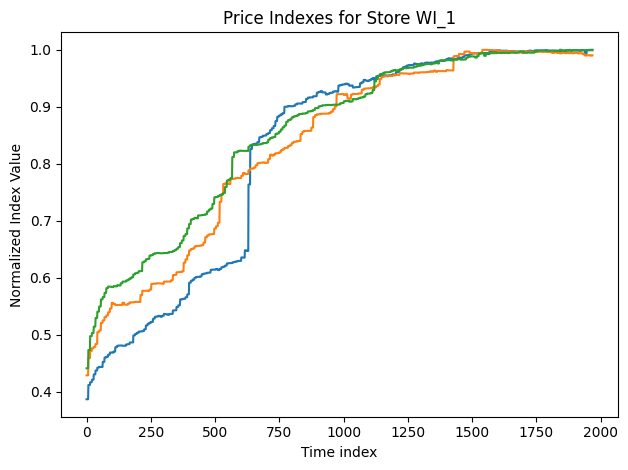

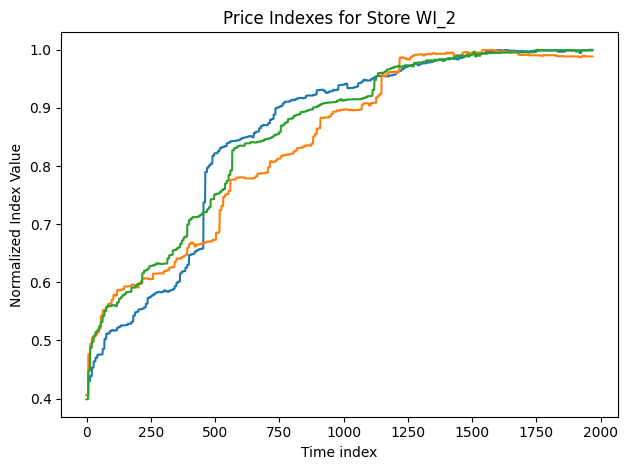

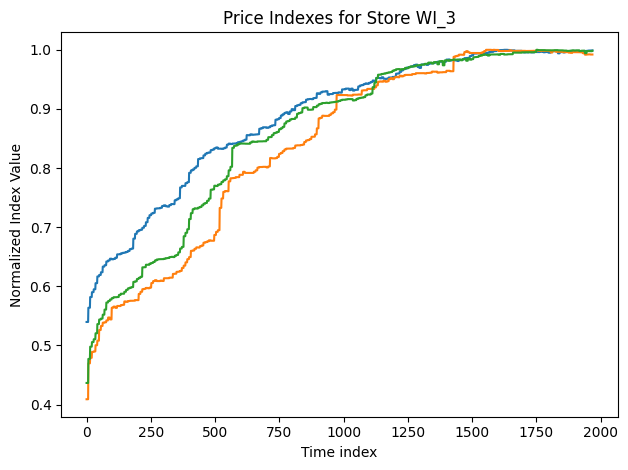

In [13]:
def plot_price_indexes(price_indexes_per_store, store_ids):
    for store in store_ids:
        fig, ax = plt.subplots()
        ax.plot(price_indexes_per_store[store].to_numpy())
        ax.set_xlabel("Time index")
        ax.set_ylabel("Normalized Index Value")
        ax.set_title(f"Price Indexes for Store {store}")

        fig.tight_layout()
        plt.show()

plot_price_indexes(price_indexes_per_store, initial_data._store_ids)

# Calculate features table for forecasting the cumulative sales behaviour

In [14]:
def calculate_initial_feature_table(
        prophet_forecasts,
        price_indexes,
        cumulative_sales,
        initial_data
):
    initial_features_table = {}

    # Prepare calendar
    calendar = initial_data._df_calendar.copy()
    calendar = calendar[
        [
            'date', 'd', 'wday', 'month',
            'event_name_1','event_type_1',
            'event_name_2','event_type_2',
            'snap_CA','snap_TX','snap_WI'
        ]
    ]
    calendar['date'] = pd.to_datetime(calendar['date'])

    # Convert global DataFrames from MultiIndex to normal columns
    df_forecasts_all = prophet_forecasts.reset_index()
    df_sales_all = cumulative_sales.reset_index()

    # Group by store_id for fast lookup
    forecast_groups = dict(tuple(df_forecasts_all.groupby('store_id')))
    sales_groups = dict(tuple(df_sales_all.groupby('store_id')))

    # price_indexes is already a dict keyed by store_id
    price_groups = price_indexes

    for store in initial_data._store_ids:

        # Extract per-store subsets
        df_forecast = forecast_groups[store][['ds', 'yhat']]
        df_sales = sales_groups[store][['d', 'y']]
        df_prices = price_groups[store]

        # Merge prices and sales on 'd'
        df = df_prices.merge(df_sales, on='d', how='left')

        # Merge with calendar to get 'date'
        df = df.merge(calendar, on='d', how='left')

        # Ensure datetime
        df['date'] = pd.to_datetime(df['date'])

        # Merge forecasts on date
        df = df.merge(
            df_forecast,
            left_on='date',
            right_on='ds',
            how='left'
        )

        df = df.drop(columns='ds')

        # Add metadata
        state = store.split('_')[0]
        df['state'] = state
        df['store_id'] = store

        snap_col = f'snap_{state}'
        df['snap'] = df[snap_col]

        # Reorder columns
        df = df[
            [
                'date','wday','month',
                'event_name_1','event_type_1',
                'event_name_2','event_type_2',
                'state','store_id','snap',
                'yhat',
                'FOODS_price_index','HOBBIES_price_index','HOUSEHOLD_price_index',
                'y'
            ]
        ]

        # Fill categorical missing values
        df[
            [
                'event_name_1','event_type_1',
                'event_name_2','event_type_2'
            ]
        ] = df[
            [
                'event_name_1','event_type_1',
                'event_name_2','event_type_2'
            ]
        ].fillna('None')

        initial_features_table[store] = df.copy()

    return initial_features_table
    
initial_feature_table = calculate_initial_feature_table(
    df_cumulative_sales_forecasts,
    price_indexes_per_store,
    cumulative_sales_time_series,
    initial_data
)
print(initial_feature_table)

{'CA_1':            date  wday  month  event_name_1 event_type_1  event_name_2  \
0    2011-01-29     1      1          None         None          None   
1    2011-01-30     2      1          None         None          None   
2    2011-01-31     3      1          None         None          None   
3    2011-02-01     4      2          None         None          None   
4    2011-02-02     5      2          None         None          None   
...         ...   ...    ...           ...          ...           ...   
1964 2016-06-15     5      6          None         None          None   
1965 2016-06-16     6      6          None         None          None   
1966 2016-06-17     7      6          None         None          None   
1967 2016-06-18     1      6          None         None          None   
1968 2016-06-19     2      6  NBAFinalsEnd     Sporting  Father's day   

     event_type_2 state store_id  snap         yhat  FOODS_price_index  \
0            None    CA     CA_1     0  

In [15]:
%timeit -n 1 -r 5 initial_feature_table = calculate_initial_feature_table(df_cumulative_sales_forecasts, price_indexes_per_store, cumulative_sales_time_series, initial_data)

109 ms ± 4.52 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)


# Add lagged values of some initial features in order to add the information of time dependency.

In [16]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

def calculate_laggs_for_feature_table(initial_features_table, future_days = 28):
    table_with_laggs = {}
    table_with_laggs_validation = {}
    keys = list(initial_features_table.keys())

    for store in keys:
        initial_table = initial_features_table[store]
        yhat_future_cols = {}
        yhat_past_cols = {}
        y_past_cols = {}
        y_future_cols = {}
        
        wday_future = {}
        month_future = {}
        event_name_1_future = {}
        event_type_1_future = {}
        event_name_2_future = {}
        event_type_2_future = {}
        
        for i in range(future_days):
            wday_future[f'wday_future_{i+1}'] = initial_table['wday'].shift(-(i + 1))
            month_future[f'month_future_{i+1}'] = initial_table['month'].shift(-(i + 1))
            event_name_1_future[f'event_name_1_future_{i+1}'] = initial_table['event_name_1'].shift(-(i + 1))
            event_type_1_future[f'event_type_1_future_{i+1}'] = initial_table['event_type_1'].shift(-(i + 1))
            event_name_2_future[f'event_name_2_future_{i+1}'] = initial_table['event_name_2'].shift(-(i + 1))
            event_type_2_future[f'event_type_2_future_{i+1}'] = initial_table['event_type_2'].shift(-(i + 1))
            yhat_future_cols[f'yhat_future_{i+1}'] = initial_table['yhat'].shift(-(i + 1))
            yhat_past_cols[f'yhat_past_-{i+1}'] = initial_table['yhat'].shift((i + 1))
            y_past_cols[f'y_past_-{i+1}'] = initial_table['y'].shift(i + 1)
            y_future_cols[f'y_future_{i+1}'] = initial_table['y'].shift(-(i + 1))
            
        
        # Concatenate all new columns at once
        future_and_past_shifts = pd.concat([
            pd.DataFrame(wday_future),
            pd.DataFrame(month_future),
            pd.DataFrame(event_name_1_future),
            pd.DataFrame(event_type_1_future),
            pd.DataFrame(yhat_future_cols),
            pd.DataFrame(yhat_past_cols),
            pd.DataFrame(y_past_cols),
            pd.DataFrame(y_future_cols)
        ], axis=1)
        
        df_store = pd.concat([initial_table, future_and_past_shifts], axis=1)
        df_store = df_store[:-28]
        table_with_laggs[store] = df_store.copy()
        table_with_laggs_validation[store] = df_store[:-29].copy()

        
    df_all = (
        pd.concat(table_with_laggs.values())
    )    

    df_all_validation = (
        pd.concat(table_with_laggs_validation.values())
        .drop(columns="date", errors="ignore")
        .dropna()
        .reset_index(drop=True)
    )  

    cat_cols = (['event_name_1','event_type_1','event_name_2','event_type_2','state','store_id']
    +[f'event_name_1_future_{i}' for i in np.arange(1,29)]
    +[f'event_type_1_future_{i}' for i in np.arange(1,29)]
    
    )
        
    for col in cat_cols:
        le = LabelEncoder()
        df_all[col] = le.fit_transform(df_all[col].astype(str))
        df_all_validation[col] = le.fit_transform(df_all_validation[col].astype(str))
        
    return df_all, df_all_validation

feature_table_with_laggs, feature_table_with_laggs_validation = calculate_laggs_for_feature_table(initial_feature_table)
print(feature_table_with_laggs)


           date  wday  month  event_name_1  event_type_1  event_name_2  \
0    2011-01-29     1      1            19             2             3   
1    2011-01-30     2      1            19             2             3   
2    2011-01-31     3      1            19             2             3   
3    2011-02-01     4      2            19             2             3   
4    2011-02-02     5      2            19             2             3   
...         ...   ...    ...           ...           ...           ...   
1936 2016-05-18     5      5            19             2             3   
1937 2016-05-19     6      5            19             2             3   
1938 2016-05-20     7      5            19             2             3   
1939 2016-05-21     1      5            19             2             3   
1940 2016-05-22     2      5            19             2             3   

      event_type_2  state  store_id  snap  ...  y_future_19  y_future_20  \
0                1      0         0

# Train the final forecasting models for cumulative sales predictions.

In [17]:
import joblib
import xgboost as xgb
from lightgbm import LGBMRegressor

def train_regressor(table_with_laggs_validation):

    label_cols = [f'y_future_{i}' for i in np.arange(1, 29)]

    # Train/test split
    features_train = table_with_laggs_validation.sample(frac=0.8, random_state=42)
    labels_train = features_train[label_cols]
    features_train = features_train.drop(columns=label_cols).reset_index(drop=True)
    labels_train = labels_train.reset_index(drop=True)

    features_test = table_with_laggs_validation.drop(features_train.index)
    labels_test = features_test[label_cols]
    features_test = features_test.drop(columns=label_cols).reset_index(drop=True)
    labels_test = labels_test.reset_index(drop=True)

    
    # Common setup
    future_horizons = labels_train.shape[1]

    
    # XGBoost
    xgb_models = []
    labels_train_pred_xgb = np.zeros_like(labels_train)
    labels_test_pred_xgb = np.zeros_like(labels_test)

    for i in range(future_horizons):
        model = xgb.XGBRegressor(
            n_estimators=110,
            max_depth=12,
            learning_rate=0.1,
            random_state=42,
            n_jobs=-1
        )

        model.fit(features_train, labels_train.iloc[:, i])
        xgb_models.append(model)

        labels_train_pred_xgb[:, i] = model.predict(features_train)
        labels_test_pred_xgb[:, i] = model.predict(features_test)

        print(f"XGB {i} out of {future_horizons}")

    rmse_train_xgb = np.sqrt(np.mean((labels_train - labels_train_pred_xgb) ** 2, axis=0))
    rmse_test_xgb = np.sqrt(np.mean((labels_test - labels_test_pred_xgb) ** 2, axis=0))

    mean_rmse_train_xgb_pct = rmse_train_xgb.mean() / labels_train.values.mean() * 100
    mean_rmse_test_xgb_pct = rmse_test_xgb.mean() / labels_test.values.mean() * 100

    print(f"XGBoost Train RMSE%: {mean_rmse_train_xgb_pct:.2f}%")
    print(f"XGBoost Test RMSE%: {mean_rmse_test_xgb_pct:.2f}%")

    # Save XGB models
    os.makedirs("xgb_models_28d", exist_ok=True)
    for i, model in enumerate(xgb_models):
        filepath = os.path.join("xgb_models_28d", f"xgb_model_h{i}.pkl")
        joblib.dump(model, filepath)
    
    
    # LightGBM
    lgbm_models = []
    labels_train_pred_lgbm = np.zeros_like(labels_train)
    labels_test_pred_lgbm = np.zeros_like(labels_test)

    for i in range(future_horizons):
        model = LGBMRegressor(
            n_estimators=700,
            learning_rate=0.1,
            max_depth=-1,
            num_leaves=128,
            subsample=0.8,
            colsample_bytree=0.5,
            random_state=42,
            n_jobs=-1
        )

        model.fit(features_train, labels_train.iloc[:, i])
        lgbm_models.append(model)

        labels_train_pred_lgbm[:, i] = model.predict(features_train)
        labels_test_pred_lgbm[:, i] = model.predict(features_test)

        print(f"LGBM {i} out of {future_horizons}")

    rmse_train_lgbm = np.sqrt(np.mean((labels_train - labels_train_pred_lgbm) ** 2, axis=0))
    rmse_test_lgbm = np.sqrt(np.mean((labels_test - labels_test_pred_lgbm) ** 2, axis=0))

    mean_rmse_train_lgbm_pct = rmse_train_lgbm.mean() / labels_train.values.mean() * 100
    mean_rmse_test_lgbm_pct = rmse_test_lgbm.mean() / labels_test.values.mean() * 100

    print(f"LightGBM Train RMSE%: {mean_rmse_train_lgbm_pct:.2f}%")
    print(f"LightGBM Test RMSE%: {mean_rmse_test_lgbm_pct:.2f}%")

    # Save LGBM models
    os.makedirs("lgbm_models_28d", exist_ok=True)
    for i, model in enumerate(lgbm_models):
        filepath = os.path.join("lgbm_models_28d", f"lgbm_model_h{i}.pkl")
        joblib.dump(model, filepath)

    return {"xgb_models": xgb_models, "lgbm_models": lgbm_models}

cumulative_sales_forecast_models = train_regressor(feature_table_with_laggs_validation)

XGB 0 out of 28
XGB 1 out of 28
XGB 2 out of 28
XGB 3 out of 28
XGB 4 out of 28
XGB 5 out of 28
XGB 6 out of 28
XGB 7 out of 28
XGB 8 out of 28
XGB 9 out of 28
XGB 10 out of 28
XGB 11 out of 28
XGB 12 out of 28
XGB 13 out of 28
XGB 14 out of 28
XGB 15 out of 28
XGB 16 out of 28
XGB 17 out of 28
XGB 18 out of 28
XGB 19 out of 28
XGB 20 out of 28
XGB 21 out of 28
XGB 22 out of 28
XGB 23 out of 28
XGB 24 out of 28
XGB 25 out of 28
XGB 26 out of 28
XGB 27 out of 28
XGBoost Train RMSE%: 1.62%
XGBoost Test RMSE%: 5.80%
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.046600 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24370
[LightGBM] [Info] Number of data points in the train set: 15072, number of used features: 210
[LightGBM] [Info] Start training from score 3448.809713
LGBM 0 out of 28
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035622 seconds.
You can set `

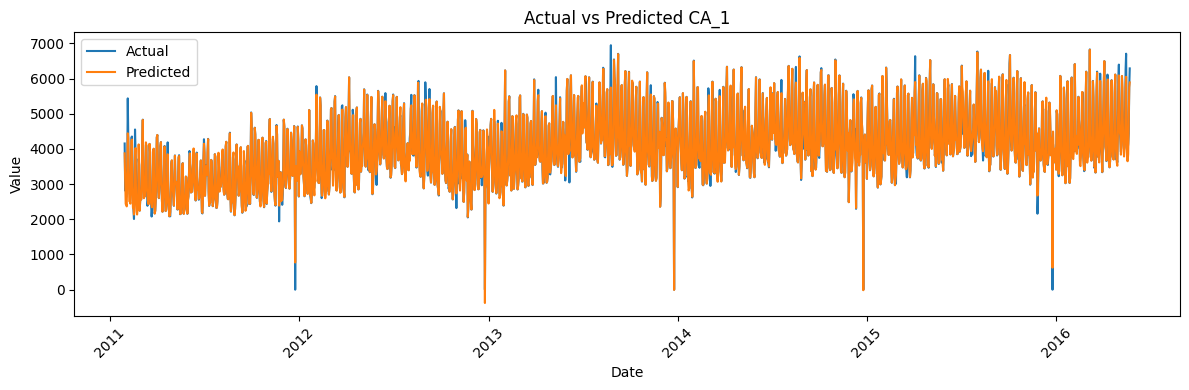

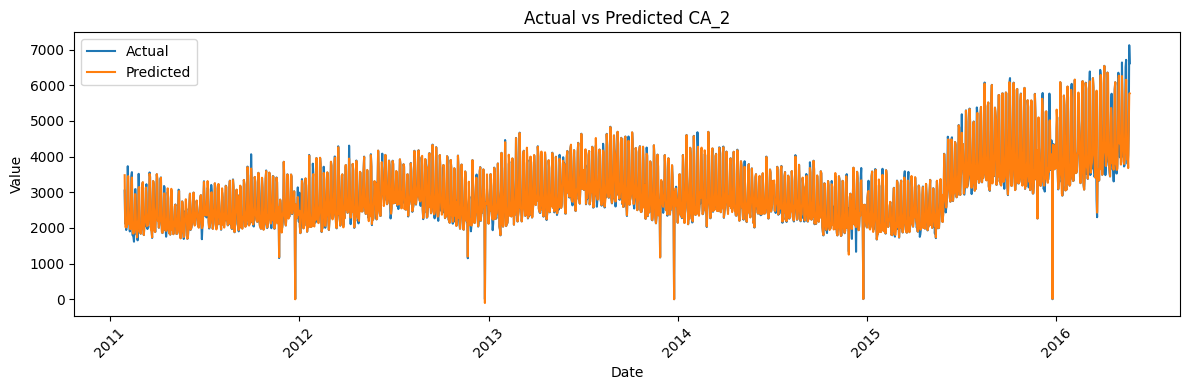

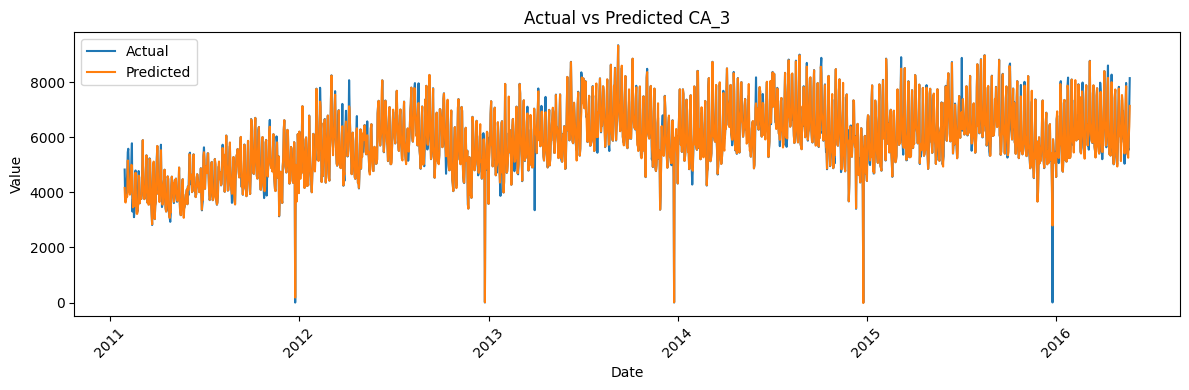

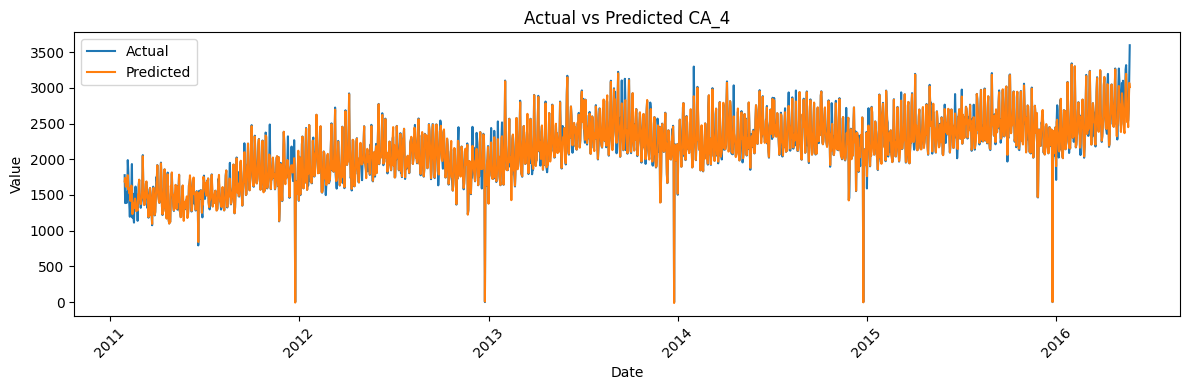

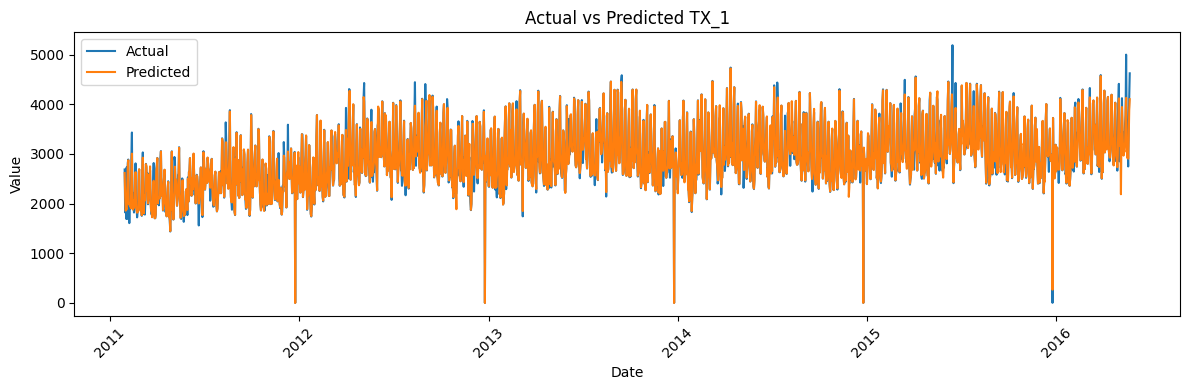

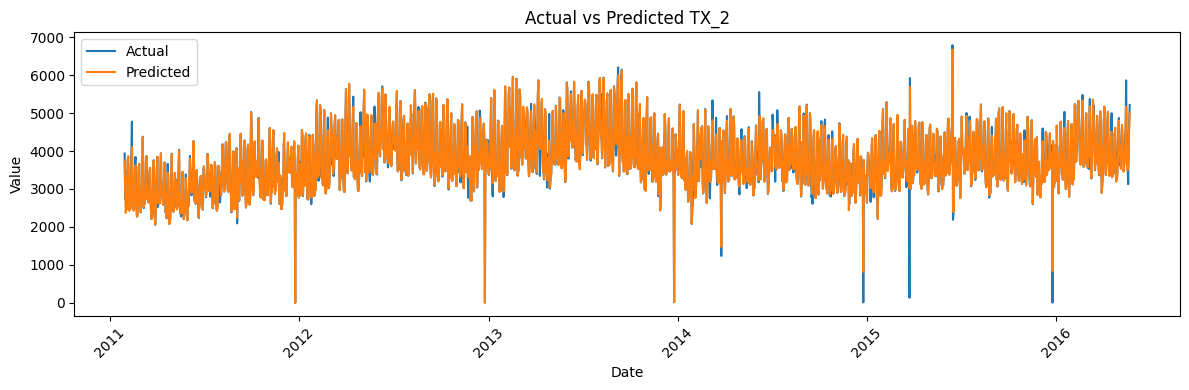

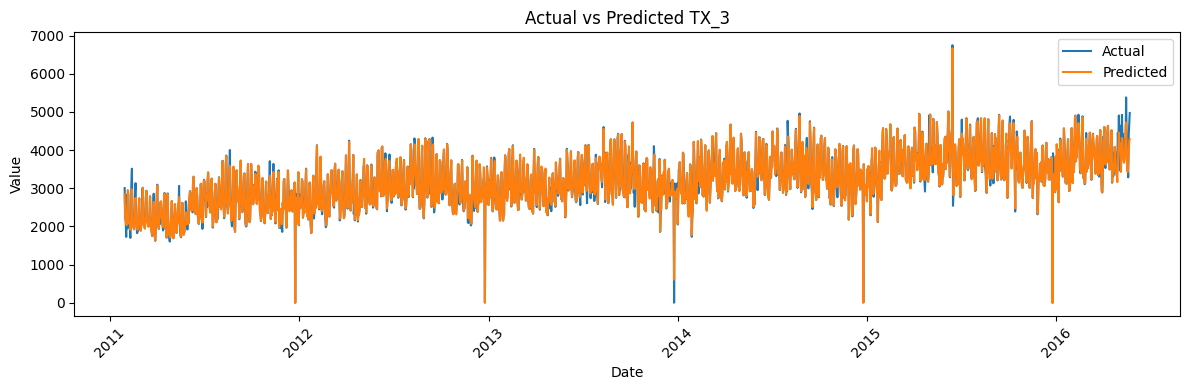

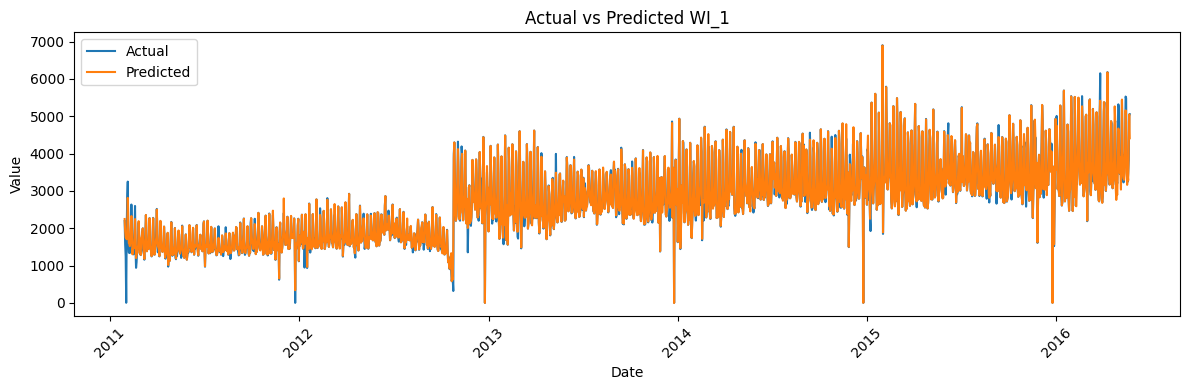

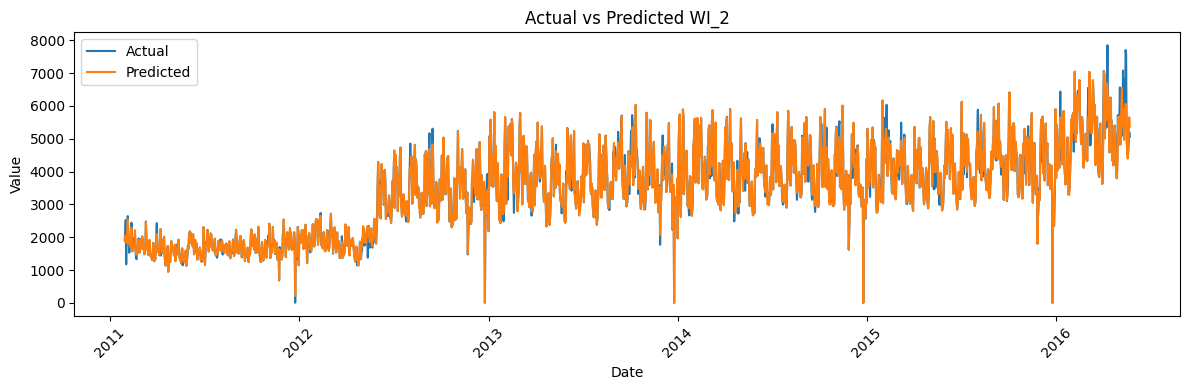

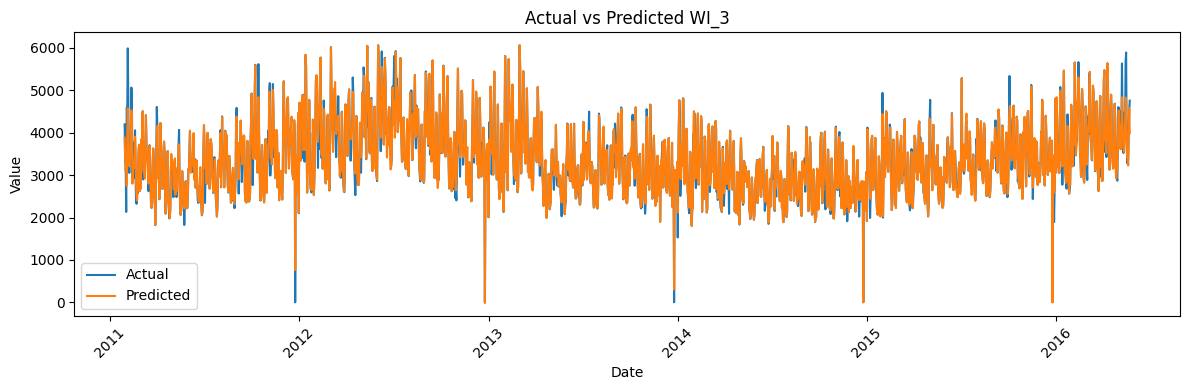

In [18]:
def evaluate_forecast_of_cumulative_sales(loaded_models, feature_table_with_laggs, store_ids):
    features_with_labels_evaluate_by_store = {
        store_id: group.copy()
        for store_id, group in feature_table_with_laggs.groupby("store_id")
    }
    n_horizons = len(loaded_models)

    eval_df_by_stores = {}

    for store in range(10):
        label_cols = [f'y_future_{i}' for i in np.arange(1,29)]
        
        features_with_labels_clean = features_with_labels_evaluate_by_store[store]

        features_evaluate = features_with_labels_clean.drop(columns=label_cols).drop(columns='date')
        labels_evaluate = features_with_labels_clean[label_cols]

        preds_all = np.column_stack([m.predict(features_evaluate) for m in loaded_models])
        pred_cols = [f"ypred_{i}" for i in range(n_horizons)]
        y_cols = [f"y_{i}" for i in range(n_horizons)]

        eval_df = pd.DataFrame(index=features_evaluate.index)
        eval_df["date"] = features_with_labels_clean["date"]
        eval_df[y_cols] = labels_evaluate.values
        eval_df[pred_cols] = preds_all
        valid_dates = set(eval_df['date'])

        eval_df_new = eval_df[['date', 'y_0', 'ypred_0']].copy()
        eval_df_new['date'] = eval_df_new['date'] + pd.Timedelta(days=1)

        eval_df_new = eval_df_new[eval_df_new['date'].isin(valid_dates)]

        n_rows = len(eval_df_new)

        offset = 28

        # Row offset before the last
        source_row_idx = n_rows - offset
        
        # Rows to replace
        target_rows_idx = range(n_rows - offset, n_rows)

        source_cols = [f'ypred_{i}' for i in range(0, offset)]

        # Extract values from the row offset before the end
        source_values = eval_df.loc[source_row_idx, source_cols].values.astype("float64")

        eval_df_new.loc[target_rows_idx, 'ypred_0'] = source_values

        # Row offset before the last
        source_row_idx = n_rows - offset
        # Rows to replace
        target_rows_idx = range(n_rows - offset, n_rows)

        eval_df_by_stores[store_ids[store]] = eval_df_new.copy()
        
    return eval_df_by_stores

def plot_cumulative_sales_preds_vs_actual(eval_df_by_stores):
    store_ids = list(eval_df_by_stores.keys())
    for store in store_ids:
        plt.figure(figsize=(12, 4))
        plt.plot(eval_df_by_stores[store]['date'], eval_df_by_stores[store]['y_0'], label='Actual')
        plt.plot(eval_df_by_stores[store]['date'], eval_df_by_stores[store]['ypred_0'], label='Predicted')
        plt.xlabel('Date')
        plt.ylabel('Value')
        plt.title(f'Actual vs Predicted {store}')
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

eval_df_by_stores = evaluate_forecast_of_cumulative_sales(cumulative_sales_forecast_models["lgbm_models"], feature_table_with_laggs, initial_data._store_ids)

plot_cumulative_sales_preds_vs_actual(eval_df_by_stores)
    

# Calculate features for predictions of dynamic normalized shares per item for each store.

In [19]:
def calculate_features_per_item(initial_data):
    df = initial_data._df_sales_evaluation.copy()

    # Identify day columns
    day_cols = df.columns[df.columns.str.match(r"^d_\d+$")]

    # Normalize per store per day (vectorized)
    df_norm = df.copy()
    df_norm[day_cols] = df[day_cols].div(
        df.groupby("store_id")[day_cols].transform("sum")
    )

    # Reshape to long format (FIX: use stack instead of melt)
    id_vars = ["store_id", "item_id", "dept_id", "cat_id", "state_id"]

    df_long = (
        df_norm
        .set_index(id_vars)[day_cols]
        .stack()
        .rename("normalized_sales")
        .reset_index()
    )

    # Rename stacked column properly
    df_long = df_long.rename(columns={"level_5": "day"})

    # Clean day column
    df_long["day"] = df_long["day"].str.replace("d_", "").astype(int)

    # Set index (no sorting needed)
    df_long = df_long.set_index(["store_id", "item_id", "day"])

    # Merge calendar features
    df_long_reset = df_long.reset_index()

    calendar_cols = [
        "d", "date", "wday", "month", "event_name_1",
        "event_type_1", "event_name_2", "event_type_2",
        "snap_CA", "snap_TX", "snap_WI"
    ]

    calendar_small = initial_data._df_calendar[calendar_cols].copy()

    calendar_small["day"] = calendar_small["d"].str.replace("d_", "").astype(int)

    df_long_reset = df_long_reset.merge(
        calendar_small.drop(columns=["d"]),
        on="day",
        how="left"
    )

    # Merge wm_yr_wk
    calendar_wm = initial_data._df_calendar[["d", "wm_yr_wk"]].copy()
    calendar_wm["day"] = calendar_wm["d"].str.replace("d_", "").astype(int)

    df_long_reset = df_long_reset.merge(
        calendar_wm.drop(columns=["d"]),
        on="day",
        how="left"
    )

    # Merge sell prices
    df_long_reset = df_long_reset.merge(
        initial_data._df_sell_prices,
        on=["store_id", "item_id", "wm_yr_wk"],
        how="left"
    )

    # SNAP feature
    store_snap_map = {
        "CA": "snap_CA",
        "TX": "snap_TX",
        "WI": "snap_WI"
    }

    df_long_reset["snap"] = df_long_reset.apply(
        lambda row: row[store_snap_map[row["store_id"][:2]]],
        axis=1
    )

    df_long_reset = df_long_reset.drop(columns=["snap_CA", "snap_TX", "snap_WI"])

    # Final formatting
    df_long_final = df_long_reset.set_index(
        ["store_id", "item_id", "day"]
    )

    cols = ["event_name_1", "event_type_1", "event_name_2", "event_type_2"]

    df_long_final[cols] = df_long_final[cols].astype("string").fillna("None")

    df_long_final["sell_price"] = df_long_final["sell_price"].fillna(0.0)
    
    return df_long_final

features_per_item_per_store = calculate_features_per_item(initial_data)
print(features_per_item_per_store)

                               dept_id   cat_id state_id  normalized_sales  \
store_id item_id       day                                                   
CA_1     HOBBIES_1_001 1     HOBBIES_1  HOBBIES       CA          0.000000   
                       2     HOBBIES_1  HOBBIES       CA          0.000000   
                       3     HOBBIES_1  HOBBIES       CA          0.000000   
                       4     HOBBIES_1  HOBBIES       CA          0.000000   
                       5     HOBBIES_1  HOBBIES       CA          0.000000   
...                                ...      ...      ...               ...   
WI_3     FOODS_3_827   1937    FOODS_3    FOODS       WI          0.000000   
                       1938    FOODS_3    FOODS       WI          0.000589   
                       1939    FOODS_3    FOODS       WI          0.000485   
                       1940    FOODS_3    FOODS       WI          0.001106   
                       1941    FOODS_3    FOODS       WI        

In [20]:
def calculate_simplest_features_and_labels_for_dynamic_shares(
    features_per_item_per_store,
    number_of_last_days_to_skip
):
    
    
    # Optional trimming
    if number_of_last_days_to_skip > 0:

        df_trimmed = features_per_item_per_store.reset_index()

        max_day = df_trimmed.groupby(["store_id", "item_id"])["day"].transform("max")
        
        df_trimmed = df_trimmed[
            df_trimmed["day"] <= (max_day - number_of_last_days_to_skip)
        ]
        
        df_trimmed = df_trimmed.set_index(["store_id", "item_id", "day"])

    else:
        df_trimmed = features_per_item_per_store.copy()

    cols = ["day",
        "store_id", "item_id", "dept_id", "cat_id", "state_id",
        "wday", "month",
        "event_name_1", "event_type_1",
        "event_name_2", "event_type_2",
        "snap", "normalized_sales", "sell_price"
    ]
    

    df_reset = df_trimmed.reset_index()

    df_features_for_shares_predictions = df_reset[cols].copy()

    cat_cols = [
        "store_id", "item_id", "dept_id", "cat_id", "state_id",
        "event_name_1", "event_type_1",
        "event_name_2", "event_type_2"
    ]
    
    for col in cat_cols:
        df_features_for_shares_predictions[col] = pd.factorize(
            df_features_for_shares_predictions[col],
            sort=False
        )[0]

    lag_cols = [
        "normalized_sales", "sell_price", "wday", "month", "snap"
    ]

    lag = 29

    # Vectorized creation of all lags
    lagged_dfs = [
        df_features_for_shares_predictions.groupby(["store_id", "item_id"])[lag_cols].shift(lag).rename(
            columns={col: f"{col}_-{lag}" for col in lag_cols}
        )
    ]
    
    # Concatenate all lagged columns to original df
    df_features_for_shares_predictions = pd.concat([df_features_for_shares_predictions] + lagged_dfs, axis=1)

    df_features_for_shares_predictions = df_features_for_shares_predictions.drop(columns="day")
    
    return df_features_for_shares_predictions

# skip last 28 days in order to make plausible predictions for evaluation of the models
df_features_for_shares_predictions = calculate_simplest_features_and_labels_for_dynamic_shares(features_per_item_per_store, 28)
print(df_features_for_shares_predictions)

          store_id  item_id  dept_id  cat_id  state_id  wday  month  \
0                0        0        0       0         0     1      1   
1                0        0        0       0         0     2      1   
2                0        0        0       0         0     3      1   
3                0        0        0       0         0     4      2   
4                0        0        0       0         0     5      2   
...            ...      ...      ...     ...       ...   ...    ...   
58254189         9     3048        6       2         2     5      4   
58254190         9     3048        6       2         2     6      4   
58254191         9     3048        6       2         2     7      4   
58254192         9     3048        6       2         2     1      4   
58254193         9     3048        6       2         2     2      4   

          event_name_1  event_type_1  event_name_2  event_type_2  snap  \
0                    0             0             0             0     0   

# Train prediction model for normalized shares per item per day.

In [21]:
def train_dynamic_shares_regressor(df_features_for_shares_predictions):
    
    def rmse(y_true, y_pred):
        return np.sqrt(np.mean((y_true - y_pred) ** 2))
    
    save_dir = "lgbm_model_dynamic_shares"
    os.makedirs(save_dir, exist_ok=True)

    label_cols = 'normalized_sales'
    df_features_for_shares_predictions = df_features_for_shares_predictions.dropna().reset_index(drop=True)

    df_sampled = df_features_for_shares_predictions.sample(frac=1, random_state=42)

    split_idx = int(0.8 * len(df_sampled))

    train_df = df_sampled.iloc[:split_idx]
    test_df = df_sampled.iloc[split_idx:]

    labels_train = train_df[label_cols]
    features_train = train_df.drop(columns=label_cols)

    labels_test = test_df[label_cols]
    features_test = test_df.drop(columns=label_cols)

    print("Training LightGBM")
    
    # LightGBM training
    lgb_model = LGBMRegressor(
        n_estimators=700,
        learning_rate=0.1,
        max_depth=-1,
        num_leaves=128,
        subsample=0.8,
        colsample_bytree=0.5,
        random_state=42,
        n_jobs=-1
    )

    lgb_model.fit(features_train, labels_train)

    labels_train_pred_lgb = lgb_model.predict(features_train)
    labels_test_pred_lgb = lgb_model.predict(features_test)

    rmse_lgb = rmse(labels_test, labels_test_pred_lgb)

    # baselines
    rmse_zero = rmse(labels_test, np.zeros_like(labels_test))
    rmse_mean = rmse(labels_test, np.full_like(labels_test, labels_train.mean()))

    print(f"LightGBM RMSE: {rmse_lgb:.9f}")
    print(f"Zero RMSE:  {rmse_zero:.9f}")
    print(f"Mean RMSE:  {rmse_mean:.9f}")

    # Save model
    filepath = os.path.join(save_dir, "lgb_model_dynamic_shares.pkl")
    joblib.dump(lgb_model, filepath)
    
    return lgb_model

dynamic_shares_model = train_dynamic_shares_regressor(df_features_for_shares_predictions)

Training LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.382025 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1122
[LightGBM] [Info] Number of data points in the train set: 45895987, number of used features: 18
[LightGBM] [Info] Start training from score 0.000328
LightGBM RMSE: 0.000845532
Zero RMSE:  0.001217538
Mean RMSE:  0.001172474


# Evaluate final predictions of resulting future sales per item per last 28 days for each store

In [22]:
df_features_for_shares_evaluation = calculate_simplest_features_and_labels_for_dynamic_shares(features_per_item_per_store, 0)

In [23]:
def calculate_predictions_dynamic_shares(model, df_features_for_shares_evaluation):
    df_features_for_shares_evaluation = df_features_for_shares_evaluation.drop(columns="normalized_sales")
    predictions_dynamic_shares = model.predict(df_features_for_shares_evaluation)

    return predictions_dynamic_shares

predictions_dynamic_shares = calculate_predictions_dynamic_shares(dynamic_shares_model, df_features_for_shares_evaluation)

print("Number of predictions: "+str(len(predictions_dynamic_shares)))
print(predictions_dynamic_shares)


Number of predictions: 59107914
[6.77068783e-06 1.80055379e-06 1.20442629e-05 ... 4.87895616e-04
 4.87913223e-04 5.07706206e-04]


In [24]:
def calculate_resulting_shares(predictions_dynamic_shares, eval_df_by_stores, features_per_item_per_store):
    # construct a new frame consisting only of necessery columns in order to produce resulting shares predictions
    resulting_shares = features_per_item_per_store.copy()
    resulting_shares = resulting_shares.reset_index()
    resulting_shares = resulting_shares[["store_id", "item_id","day","date", "normalized_sales"]]
    resulting_shares["pred_norm_shares"] = predictions_dynamic_shares

    # Ensure non-negative
    resulting_shares["pred_norm_shares"] = resulting_shares["pred_norm_shares"].clip(lower=0)

    # Normalize per store/day
    group_sum = resulting_shares.groupby(["store_id", "day"])["pred_norm_shares"].transform("sum")

    # Avoid division by zero
    resulting_shares["pred_norm_shares"] = resulting_shares["pred_norm_shares"] / group_sum.replace(0, 1)

    df_store_preds = pd.concat(
        eval_df_by_stores,
        names=["store_id"]
    ).reset_index(level=0).reset_index(drop=True)

    resulting_shares["date"] = pd.to_datetime(resulting_shares["date"])

    df_store_preds["date"] = pd.to_datetime(df_store_preds["date"])

    df_merged = resulting_shares.merge(
        df_store_preds[["store_id", "date", "ypred_0"]],
        on=["store_id", "date"],
        how="left"
    )
    df_merged = df_merged.fillna(0.0).infer_objects(copy=False)
    df_merged["final_pred"] = (
        df_merged["pred_norm_shares"] * df_merged["ypred_0"] + 0.5
    ).astype(int)  

    df_merged = df_merged.drop(columns=["normalized_sales", "date", "pred_norm_shares", "ypred_0"])

    item_order = df_merged[["store_id", "item_id"]].drop_duplicates()
    
    df_wide = (
        df_merged.pivot(
            index=["store_id", "item_id"],
            columns="day",
            values="final_pred"
        )
    )
    df_wide = df_wide.loc[
        pd.MultiIndex.from_frame(item_order)
    ]
    df_wide.columns = [f"day_{col}" for col in df_wide.columns]
    
    return df_wide

predictions = calculate_resulting_shares(predictions_dynamic_shares, eval_df_by_stores, features_per_item_per_store)
print(predictions)

                        day_1  day_2  day_3  day_4  day_5  day_6  day_7  \
store_id item_id                                                          
CA_1     HOBBIES_1_001    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
         HOBBIES_1_002    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
         HOBBIES_1_003    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
         HOBBIES_1_004    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
         HOBBIES_1_005    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
...                       ...    ...    ...    ...    ...    ...    ...   
WI_3     FOODS_3_823      0.0    2.0    2.0    2.0    2.0    2.0    2.0   
         FOODS_3_824      0.0    3.0    2.0    2.0    2.0    2.0    3.0   
         FOODS_3_825      0.0    3.0    2.0    2.0    2.0    2.0    2.0   
         FOODS_3_826      0.0    0.0    0.0    0.0    0.0    0.0    0.0   
         FOODS_3_827      0.0    0.0    0.0    0.0    0.0    0.0    0.0   

                        

# Make final score evaluation.

In [25]:
class WRMSSEEvaluator:
    def __init__(self, train_df, calendar, prices):
        """
        train_df: MUST be sales_train_evaluation.csv for correct WRMSSE
        calendar: calendar.csv
        prices: sell_prices.csv
        """

        self.train_df = train_df.copy()
        self.calendar = calendar
        self.prices = prices

        self.id_cols = ["item_id", "dept_id", "cat_id", "store_id", "state_id"]
        self.d_cols = [c for c in train_df.columns if c.startswith("d_")]

        # 12 hierarchical aggregation levels (official M5)
        self.levels = [
            [],
            ["state_id"],
            ["store_id"],
            ["cat_id"],
            ["dept_id"],
            ["state_id", "cat_id"],
            ["state_id", "dept_id"],
            ["store_id", "cat_id"],
            ["store_id", "dept_id"],
            ["item_id"],
            ["item_id", "state_id"],
            ["item_id", "store_id"],
        ]

        self._prepare_data()

    
    # PREP PIPELINE
    def _prepare_data(self):
        self._build_aggregation()
        self._compute_scales()
        self._compute_weights()

    
    # AGGREGATION MATRIX
    def _build_aggregation(self):
        sales = self.train_df[self.d_cols].values
        n_series = sales.shape[0]

        agg_matrices = []
        all_ids = []

        for group_cols in self.levels:
            if len(group_cols) == 0:
                mat = np.ones((1, n_series), dtype=np.float32)
                ids = np.array(["Total"])
            else:
                group_ids = self.train_df[group_cols].astype(str).agg("_".join, axis=1)
                unique_groups, group_index = np.unique(group_ids, return_inverse=True)

                mat = np.zeros((len(unique_groups), n_series), dtype=np.float32)
                mat[group_index, np.arange(n_series)] = 1

                ids = unique_groups

            agg_matrices.append(mat)
            all_ids.append(ids)

        self.agg_matrix = np.vstack(agg_matrices)
        self.all_ids = np.concatenate(all_ids)

        self.train_series = self.agg_matrix @ sales

    
    # SCALE (RMSSE denominator)
    def _compute_scales(self):
        scales = []

        for series in self.train_series:
            # Remove leading zeros (IMPORTANT for M5)
            non_zero_idx = np.argmax(series > 0)
            trimmed = series[non_zero_idx:]

            if len(trimmed) <= 1:
                scales.append(1e-8)
            else:
                diff = np.diff(trimmed)
                scales.append(np.mean(diff ** 2))

        self.scale = np.array(scales)

    
    # WEIGHTS (Revenue-based)
    def _compute_weights(self):
        last_28 = self.d_cols[-28:]

        # Map d -> week
        d_to_week = self.calendar.set_index("d")["wm_yr_wk"].to_dict()
        weeks = np.array([d_to_week[d] for d in last_28])

        sales = self.train_df.copy()
        sales["key"] = sales["store_id"] + "_" + sales["item_id"]

        price_df = self.prices.copy()
        price_df["key"] = price_df["store_id"] + "_" + price_df["item_id"]

        price_map = price_df.set_index(["key", "wm_yr_wk"])["sell_price"]

        sales_values = sales[last_28].values
        price_matrix = np.zeros_like(sales_values, dtype=np.float32)

        keys = sales["key"].values

        for i, week in enumerate(weeks):
            price_matrix[:, i] = price_map.reindex(
                pd.MultiIndex.from_arrays([keys, [week] * len(keys)])
            ).values

        revenue = sales_values * price_matrix

        # Aggregate revenue correctly
        agg_revenue = self.agg_matrix @ revenue
        weights = agg_revenue.sum(axis=1)

        self.weights = weights / weights.sum()

    
    # SCORE FUNCTION
    def score(self, preds, actuals):
        """
        preds: numpy array (30490, 28)
        actuals: numpy array (30490, 28)
        """

        preds_agg = self.agg_matrix @ preds
        actuals_agg = self.agg_matrix @ actuals

        mse = np.mean((actuals_agg - preds_agg) ** 2, axis=1)
        rmsse = np.sqrt(mse / self.scale)

        return np.sum(self.weights * rmsse)

print("Initializing evaluator")
evaluator = WRMSSEEvaluator(initial_data._df_sales_evaluation, initial_data._df_calendar, initial_data._df_sell_prices)

actuals = initial_data._df_sales_evaluation.iloc[:, -28:].values  # last 28 days
preds_random = np.random.rand(30490, 28)        
preds_zeros = np.zeros((30490, 28), dtype=int)

# Sanity check:
print("WRMSSE_actual_actual: ", evaluator.score(actuals, actuals))  # should be ~0

score_random = evaluator.score(preds_random, actuals)
print("WRMSSE_random:", score_random)

score_zeros = evaluator.score(preds_zeros, actuals)
print("WRMSSE_zeros:", score_zeros)

preds_dynamic_shares = predictions.iloc[:, -28:].values
score_dynamic_shares = evaluator.score(preds_dynamic_shares, actuals)
print("WRMSSE_dynamic_shares:", score_dynamic_shares)
print("Contest winning WRMSSE score was 0.52")

Initializing evaluator
WRMSSE_actual_actual:  0.0
WRMSSE_random: 3.701436143248988
WRMSSE_zeros: 5.449542341759063
WRMSSE_dynamic_shares: 0.8098426506629091
Contest winning WRMSSE score was 0.52


# Conclusion
### The model achieved a WRMSSE of 0.81, compared to the winning benchmark of 0.52. This indicates that model captures a significant portion of the underlying demand structure and builds a solid baseline solution for the one of the hardest real world machine learning competition datasets.